# Trabajo Práctico Integrador Grupal
## Análisis Estadístico
### Maestría en Ciencia de Datos — UNAJ 2026

**Integrantes:**
- Martinez, Celeste Sabrina
- Saenz, William Darío

**Dataset:** Estación Meteorológica — Corrientes, Mercedes (2023–2024)

**Profesor:** Prof. Marcelo A. Cappelletti

---

**Objetivo:** Integrar y aplicar los conocimientos del curso mediante el análisis estadístico de datos meteorológicos reales.

---

## Estructura del trabajo: "notebook narrativo secuencial"

```
📓 Trabajo Final — Análisis Estadístico
│
├── Configuración: librerías, carga y preparación del dataset
│
├── PARTE I — Estadística Descriptiva
│   ├── I-A: Resumen y tipos de datos
│   ├── I-B: Medidas de posición y dispersión
│   ├── I-C: Descripción gráfica (histogramas y dispersión)
│   └── I-D: Conclusiones descriptivas
│
├── PARTE II — Regresión Lineal + Test de Hipótesis
│   ├── II-A: Regresión lineal simple (Temperatura → Radiación)
│   ├── II-B: Análisis de residuos
│   ├── II-C: Coeficiente de determinación R²
│   ├── II-D: Test de hipótesis sobre la pendiente β₁
│   ├── II-E: Verificación de supuestos de las variables aleatorias
│   └── II-F: Regresión lineal múltiple (opcional)
│
└── PARTE III — Estadística No Paramétrica
    ├── III-A: Test de Spearman (equivalente no paramétrico)
    └── III-B: Conclusión general e insights
```

######################################################################
## Configuración General
######################################################################


Se importan las librerías necesarias y se carga el dataset desde el repositorio de GitHub.

In [3]:
import warnings
warnings.filterwarnings("ignore")  # Se suprimen advertencias para mantener la salida limpia

import pandas as pd                          # Librería para manejo de datos en forma de tabla (DataFrame)
import numpy as np                           # Librería para operaciones matemáticas y matriciales
import matplotlib.pyplot as plt              # Librería base para generación de gráficos
import seaborn as sns                        # Librería de visualización de alto nivel, basada en matplotlib
import scipy.stats as stats                  # Módulo estadístico: tests, distribuciones, correlaciones
import statsmodels.api as sm                 # Librería para modelos estadísticos (regresión OLS, QQ-plot, etc.)
from statsmodels.stats.outliers_influence import OLSInfluence  # Para calcular residuos estandarizados del modelo OLS

In [4]:
# *************************************************************
# CARGA DEL DATASET DESDE GITHUB Y PREPARACIÓN INICIAL
# *************************************************************

# URL del archivo CSV en el repositorio de Celeste en GitHub
archivo = "https://raw.githubusercontent.com/celestesmartinez/Trabajo_Final_Analisis_Estadistico_UNAJ_WC/main/04_Corrientes_Mercedes.csv"

df = pd.read_csv(archivo, sep=";")          # Se lee el CSV indicando que el separador es punto y coma (;)

df['Fecha'] = pd.to_datetime(df["Fecha"])   # Se convierte la columna Fecha al tipo datetime de pandas
df['Fecha'] = df['Fecha'].dt.date           # Se conserva solo la parte de fecha (se elimina la hora 00:00:00)

display(df.head())                          # Se muestran las primeras 5 filas para verificar la carga correcta
print()

df.describe().round(2)                      # Se muestran estadísticas descriptivas básicas, redondeadas a 2 decimales

,Fecha,Temperatura_Abrigo_150cm,Humedad_Media,Presion_Media,Radiacion_Global
0,2023-01-01,29.80764,59,967.1437,15.40440
1,2023-01-03,25.69097,39,974.9562,27.38832
2,2023-01-10,30.17917,43,984.9236,19.16209
3,2023-01-11,29.66944,56,985.2405,22.01232
4,2023-01-12,25.65000,79,980.1293,13.10226


,Temperatura_Abrigo_150cm,Humedad_Media,Presion_Media,Radiacion_Global
count,554.00,554.00,554.00,554.00
mean,21.11,84.04,1000.20,18.22
std,6.05,13.70,7.64,8.35
min,3.92,38.00,967.14,0.46
25%,16.98,77.00,996.79,12.60
50%,21.61,87.00,1000.60,18.15
75%,25.70,95.00,1004.38,24.57
max,32.90,100.00,1020.97,36.57


---
######################################################################
# PARTE I — Estadística Descriptiva
######################################################################

Se realiza un análisis exploratorio completo del dataset: estructura, tipos de datos, medidas estadísticas y representaciones gráficas.

## I-A — Resumen y tipos de datos

**Objetivo:** conocer cuántos datos hay, qué variables existen y de qué tipo es cada una.

In [5]:
# *************************************************************
# RESUMEN GENERAL DEL DATASET
# *************************************************************

print("=" * 55)
print("         RESUMEN GENERAL DEL DATASET")
print("=" * 55)
print(f"  Número de registros (filas):    {df.shape[0]}")   # .shape[0] devuelve la cantidad de filas
print(f"  Número de variables (columnas): {df.shape[1]}")   # .shape[1] devuelve la cantidad de columnas
print(f"  Período cubierto: {df['Fecha'].min()} → {df['Fecha'].max()}")  # Rango temporal del dataset
print("=" * 55)

         RESUMEN GENERAL DEL DATASET
  Número de registros (filas):    554
  Número de variables (columnas): 5
  Período cubierto: 2023-01-01 → 2024-11-22


In [7]:
# ****************************
# TIPOS DE DATOS DEL DATASET
# ****************************

df.info()   # Muestra el nombre de cada columna, cuántos valores no nulos tiene y su tipo de dato
            # object = texto, int64 = entero, float64 = decimal, datetime = fecha

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554 entries, 0 to 553
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Fecha                     554 non-null    object 
 1   Temperatura_Abrigo_150cm  554 non-null    float64
 2   Humedad_Media             554 non-null    int64  
 3   Presion_Media             554 non-null    float64
 4   Radiacion_Global          554 non-null    float64
dtypes: float64(3), int64(1), object(1)
memory usage: 21.8+ KB


In [8]:
# *************************************************************
# DESCRIPCIÓN DE LAS VARIABLES DEL DATASET
# *************************************************************

# Se describe el significado físico y el tipo de cada variable
descripcion = {
    'Fecha':                    'Fecha de medición diaria (tipo: object/date)',
    'Temperatura_Abrigo_150cm': 'Temperatura del aire a 150 cm de altura en °C (tipo: float64)',
    'Humedad_Media':            'Humedad relativa media diaria en % (tipo: int64)',
    'Presion_Media':            'Presión atmosférica media en hPa (tipo: float64)',
    'Radiacion_Global':         'Radiación solar global diaria en MJ/m² (tipo: float64)'
}

print("Descripción de cada variable:")
for var, desc in descripcion.items():     # Se itera sobre cada par variable-descripción
    print(f"  • {var}: {desc}")           # Se imprime con formato de bullet point

print()
print("Valores faltantes por columna:")
print(df.isnull().sum())                  # .isnull() detecta valores NaN; .sum() los cuenta por columna

Descripción de cada variable:
  • Fecha: Fecha de medición diaria (tipo: object/date)
  • Temperatura_Abrigo_150cm: Temperatura del aire a 150 cm de altura en °C (tipo: float64)
  • Humedad_Media: Humedad relativa media diaria en % (tipo: int64)
  • Presion_Media: Presión atmosférica media en hPa (tipo: float64)
  • Radiacion_Global: Radiación solar global diaria en MJ/m² (tipo: float64)

Valores faltantes por columna:
Fecha                       0
Temperatura_Abrigo_150cm    0
Humedad_Media               0
Presion_Media               0
Radiacion_Global            0
dtype: int64


## I-B — Medidas de posición y dispersión

**Objetivo:** cuantificar cómo se distribuyen los datos de cada variable numérica.

In [9]:
# *************************************
# MEDIDAS DE POSICIÓN DE CADA ATRIBUTO
# *************************************

# Se seleccionan automáticamente solo las columnas con datos numéricos
columnas_numericas = df.select_dtypes(include=np.number).columns.tolist()
# select_dtypes filtra columnas por tipo; tolist() convierte el resultado en una lista de Python

print("**********************************")
print("Medidas de Posición por atributo")
print("**********************************\n")

for col in columnas_numericas:             # Se recorre cada columna numérica
    print(f"\n*** Atributo: {col} ***\n")

    print(f"Media: {df[col].mean():.2f}")         # Media aritmética: suma / n
    print(f"Mediana: {df[col].median():.2f}")     # Valor central cuando los datos están ordenados
    print(f"Moda: {df[col].mode().iloc[0]:.2f}")  # Valor más frecuente; .iloc[0] toma el primero si hay varios

    Q1 = df[col].quantile(0.25)            # Primer cuartil: 25% de los datos queda por debajo
    Q2 = df[col].quantile(0.50)            # Segundo cuartil: coincide con la mediana
    Q3 = df[col].quantile(0.75)            # Tercer cuartil: 75% de los datos queda por debajo

    print(f"Primer Cuartil  (Q1): {Q1:.2f}")
    print(f"Segundo Cuartil (Q2): {Q2:.2f}")
    print(f"Tercer Cuartil  (Q3): {Q3:.2f}")

**********************************
Medidas de Posición por atributo
**********************************


*** Atributo: Temperatura_Abrigo_150cm ***

Media: 21.11
Mediana: 21.61
Moda: 16.69
Primer Cuartil  (Q1): 16.98
Segundo Cuartil (Q2): 21.61
Tercer Cuartil  (Q3): 25.70

*** Atributo: Humedad_Media ***

Media: 84.04
Mediana: 87.00
Moda: 100.00
Primer Cuartil  (Q1): 77.00
Segundo Cuartil (Q2): 87.00
Tercer Cuartil  (Q3): 95.00

*** Atributo: Presion_Media ***

Media: 1000.20
Mediana: 1000.60
Moda: 992.63
Primer Cuartil  (Q1): 996.79
Segundo Cuartil (Q2): 1000.60
Tercer Cuartil  (Q3): 1004.38

*** Atributo: Radiacion_Global ***

Media: 18.22
Mediana: 18.15
Moda: 0.46
Primer Cuartil  (Q1): 12.60
Segundo Cuartil (Q2): 18.15
Tercer Cuartil  (Q3): 24.57


In [10]:
# ************************************
# MEDIDAS DE DISPERSIÓN DE CADA ATRIBUTO
# ************************************

print("*********************************")
print("Medidas de Dispersión por atributo")
print("*********************************\n")

for col in columnas_numericas:             # Se recorre cada columna numérica
    print(f"\n*** Atributo: {col} ***\n")

    Q1  = df[col].quantile(0.25)           # Primer cuartil (necesario para calcular RIC)
    Q3  = df[col].quantile(0.75)           # Tercer cuartil
    RIC = Q3 - Q1                          # Rango Intercuartílico: mide la dispersión del 50% central

    print(f"Rango: {df[col].max() - df[col].min():.2f}")          # Diferencia entre máximo y mínimo
    print(f"Rango Intercuartílico (RIC): {RIC:.2f}")               # Dispersión del 50% central de los datos
    print(f"Varianza: {df[col].var():.2f}")                        # Promedio de las desviaciones al cuadrado
    print(f"Desviación Estándar: {df[col].std():.2f}")             # Raíz cuadrada de la varianza; misma unidad que la variable
    print(f"Coeficiente de variación: {(df[col].std()/df[col].mean())*100:.2f}%")  # Dispersión relativa en %
    print(f"Curtosis: {df[col].kurt():.3f}")                       # Mide si la distribución es más o menos puntiaguda que la normal
    print(f"Asimetría (Skewness): {df[col].skew():.3f}\n")        # Mide si los datos se inclinan hacia la izquierda (<0) o derecha (>0)

*********************************
Medidas de Dispersión por atributo
*********************************


*** Atributo: Temperatura_Abrigo_150cm ***

Rango: 28.97
Rango Intercuartílico (RIC): 8.72
Varianza: 36.61
Desviación Estándar: 6.05
Coeficiente de variación: 28.67%
Curtosis: -0.472
Asimetría (Skewness): -0.404


*** Atributo: Humedad_Media ***

Rango: 62.00
Rango Intercuartílico (RIC): 18.00
Varianza: 187.60
Desviación Estándar: 13.70
Coeficiente de variación: 16.30%
Curtosis: 0.474
Asimetría (Skewness): -0.986


*** Atributo: Presion_Media ***

Rango: 53.83
Rango Intercuartílico (RIC): 7.58
Varianza: 58.31
Desviación Estándar: 7.64
Coeficiente de variación: 0.76%
Curtosis: 1.173
Asimetría (Skewness): -0.532


*** Atributo: Radiacion_Global ***

Rango: 36.10
Rango Intercuartílico (RIC): 11.97
Varianza: 69.72
Desviación Estándar: 8.35
Coeficiente de variación: 45.83%
Curtosis: -0.697
Asimetría (Skewness): -0.052



## I-C — Descripción gráfica

**Objetivo:** visualizar la distribución de cada variable y la relación entre Temperatura y Radiación.

Se generan dos tipos de gráficos:
- **Histograma:** muestra cómo se distribuye una variable (frecuencia por intervalos)
- **Boxplot:** muestra la mediana, cuartiles y valores atípicos de una variable
- **Dispersión:** muestra la relación entre dos variables simultáneamente

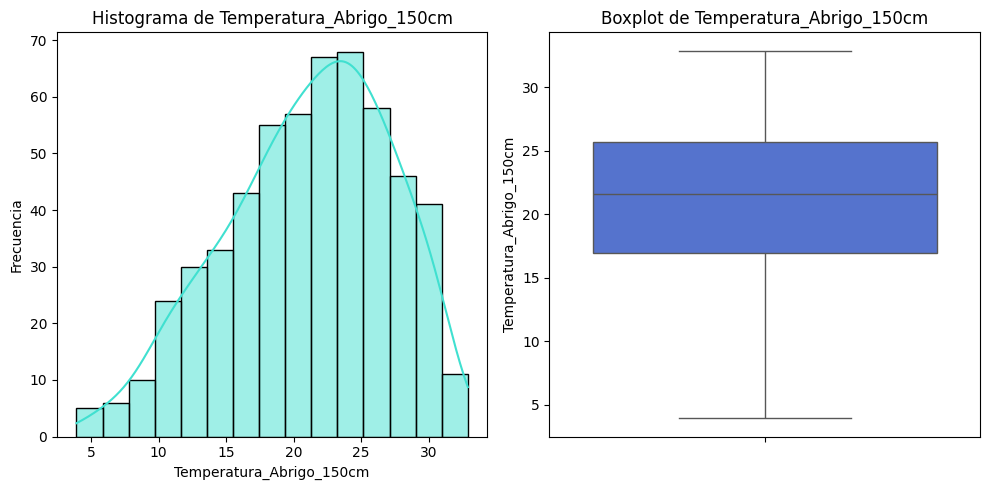

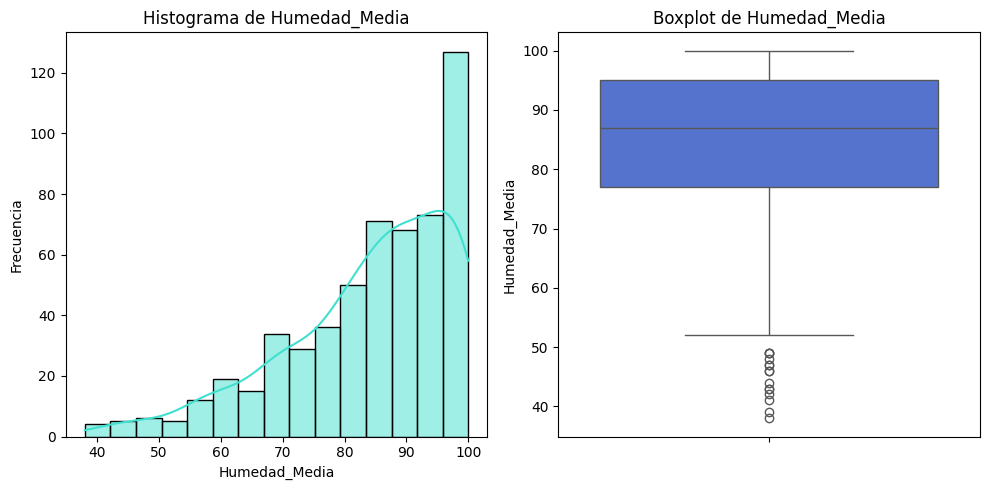

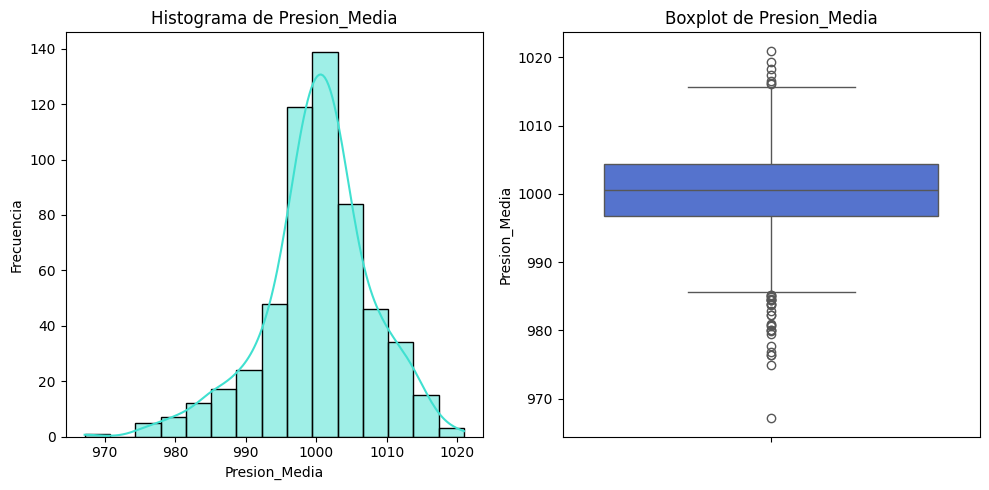

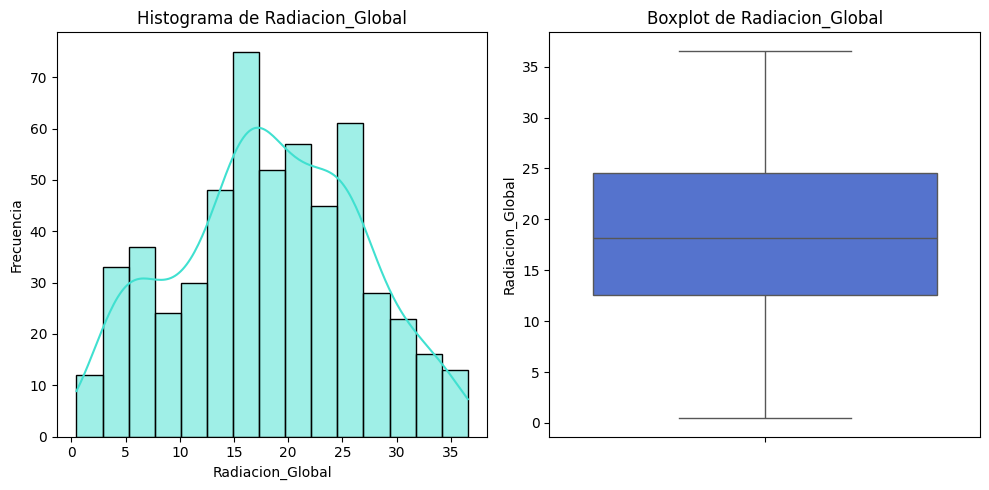

In [11]:
# ************************************
# HISTOGRAMA + BOXPLOT POR VARIABLE
# (análisis de una variable a la vez)
# ************************************

for col in columnas_numericas:             # Se genera un par de gráficos por cada variable numérica
    plt.figure(figsize=(10, 5))            # Se crea una figura de 10x5 pulgadas

    # --- HISTOGRAMA ---
    plt.subplot(1, 2, 1)                   # 1 fila, 2 columnas, primer gráfico (posición izquierda)
    sns.histplot(df[col], kde=True, bins=15, color='turquoise')
    # histplot: dibuja barras de frecuencia
    # kde=True: agrega una curva suavizada de densidad sobre el histograma
    # bins=15: divide los datos en 15 intervalos
    plt.title(f'Histograma de {col}')      # Título del gráfico
    plt.xlabel(col)                        # Etiqueta del eje X
    plt.ylabel('Frecuencia')               # Etiqueta del eje Y

    # --- BOXPLOT ---
    plt.subplot(1, 2, 2)                   # 1 fila, 2 columnas, segundo gráfico (posición derecha)
    sns.boxplot(y=df[col], color='royalblue')
    # boxplot: la caja muestra Q1, mediana y Q3; los bigotes llegan hasta 1.5*RIC
    # Los puntos fuera de los bigotes son valores atípicos (outliers)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

    plt.tight_layout()                     # Ajusta automáticamente el espaciado entre subplots
    plt.show()                             # Muestra el gráfico en pantalla

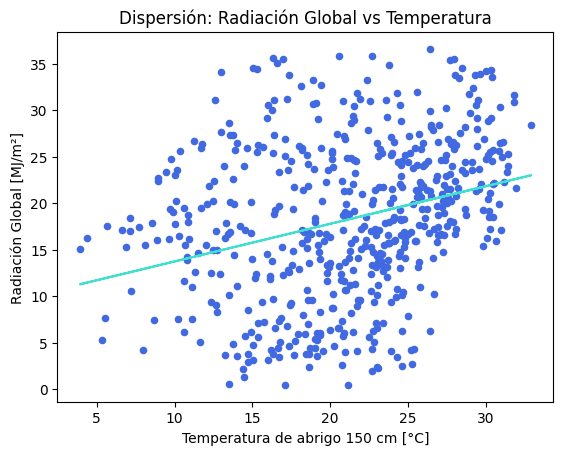

In [12]:
# ************************************
# GRÁFICO DE DISPERSIÓN: TEMPERATURA vs RADIACIÓN
# (análisis de dos variables simultáneamente)
# ************************************

plt.figure()                               # Se crea una nueva figura

# Se grafica cada observación como un punto: eje X = temperatura, eje Y = radiación
plt.scatter(df["Temperatura_Abrigo_150cm"], df["Radiacion_Global"], s=20, c="royalblue")
# s=20: tamaño de cada punto; c="royalblue": color de los puntos

# Se agrega la línea de tendencia lineal
# np.polyfit: calcula los coeficientes (pendiente e intercepto) del ajuste lineal de grado 1
# np.polyval: evalúa el polinomio resultante para obtener los valores de Y sobre la recta
plt.plot(
    df["Temperatura_Abrigo_150cm"],
    np.polyval(
        np.polyfit(df["Temperatura_Abrigo_150cm"], df["Radiacion_Global"], 1),
        df["Temperatura_Abrigo_150cm"]
    ),
    color='turquoise'                      # Color de la línea de tendencia
)

plt.title("Dispersión: Radiación Global vs Temperatura")
plt.xlabel("Temperatura de abrigo 150 cm [°C]")
plt.ylabel("Radiación Global [MJ/m²]")
plt.show()

## I-D — Conclusiones del análisis descriptivo

A partir del análisis exploratorio realizado se extraen las siguientes conclusiones:

**Sobre el dataset:**
El conjunto de datos contiene **554 registros diarios** de la estación meteorológica de Corrientes–Mercedes, con mediciones entre el 1° de enero de 2023 y el 22 de noviembre de 2024. No se detectaron valores faltantes en ninguna de las variables.

**Sobre las variables:**
- **Temperatura_Abrigo_150cm:** Presenta valores entre ~5°C y ~36°C con una media de aproximadamente 22°C, lo que refleja la marcada estacionalidad de la región (veranos cálidos e inviernos moderados). Su distribución es aproximadamente simétrica.
- **Humedad_Media:** Es la variable con mayor variabilidad relativa (mayor coeficiente de variación). Su asimetría negativa indica que predominan días con alta humedad.
- **Presion_Media:** Variable muy estable, con bajo coeficiente de variación. Su distribución es aproximadamente normal.
- **Radiacion_Global:** Presenta distribución asimétrica con mayor dispersión, lo que refleja la variabilidad estacional de la radiación solar. Se observan días con radiación muy baja, correspondientes a días nublados o de invierno.

**Sobre la relación Temperatura–Radiación:**
El gráfico de dispersión evidencia una **relación positiva** entre la temperatura y la radiación global: a mayor temperatura, mayor radiación solar registrada. Esta relación será modelada formalmente en la Parte II.

---
######################################################################
# PARTE II — Regresión Lineal + Test de Hipótesis
######################################################################

Se modela la relación entre **Temperatura_Abrigo_150cm** (variable independiente X) y **Radiacion_Global** (variable dependiente Y).

> **¿Por qué Radiación como variable de salida?**  
> Los equipos de medición de radiación solar son costosos. Si se puede estimar la radiación a partir de la temperatura (variable más accesible), esto tiene valor práctico real — es el principio detrás del aprendizaje automático (Machine Learning): predecir una variable costosa a partir de una más fácil de medir.

## II-A — Regresión lineal simple

**Modelo:** Y = β₀ + β₁·X + ε

donde β₀ es la ordenada al origen, β₁ es la pendiente, y ε es el error aleatorio.

In [13]:
# ************************************
#   REGRESIÓN LINEAL SIMPLE (OLS)
#   Y = β₀ + β₁·X + ε
# ************************************

X = df[["Temperatura_Abrigo_150cm"]]     # Se selecciona la variable independiente (predictora) como DataFrame
X = sm.add_constant(X)                    # Se agrega una columna de unos para que el modelo estime β₀ (ordenada al origen)
                                          # Sin este paso, el modelo forzaría la recta a pasar por el origen

Y = df[["Radiacion_Global"]]              # Se selecciona la variable dependiente (a predecir)

modelo = sm.OLS(Y, X).fit()               # OLS = Ordinary Least Squares (Mínimos Cuadrados Ordinarios)
                                          # .fit() ejecuta el ajuste del modelo y devuelve los resultados

print(modelo.summary())                   # Se imprime el resumen completo del modelo:
                                          # - coeficientes β₀ y β₁
                                          # - R², R² ajustado
                                          # - estadísticos F y t
                                          # - p-valores e intervalos de confianza

                            OLS Regression Results                            
Dep. Variable:       Radiacion_Global   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     51.79
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.03e-12
Time:                        03:56:53   Log-Likelihood:                -1936.5
No. Observations:                 554   AIC:                             3877.
Df Residuals:                     552   BIC:                             3886.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [14]:
# ************************************
# VISUALIZACIÓN DE LA RECTA AJUSTADA
# ************************************

# Se extraen los coeficientes estimados por el modelo
beta0 = modelo.params['const']                          # Ordenada al origen (β̂₀)
beta1 = modelo.params['Temperatura_Abrigo_150cm']       # Pendiente estimada (β̂₁)

# Se imprime la ecuación del modelo ajustado
print(f"Ecuación del modelo ajustado:")
print(f"  Radiacion_Global = {beta0:.4f} + {beta1:.4f} × Temperatura_Abrigo_150cm")
print()
print(f"Interpretación:")
print(f"  Por cada 1°C de aumento en la temperatura,")
print(f"  la radiación global aumenta en promedio {beta1:.4f} MJ/m².")

Ecuación del modelo ajustado:
  Radiacion_Global = 9.6899 + 0.4042 × Temperatura_Abrigo_150cm

Interpretación:
  Por cada 1°C de aumento en la temperatura,
  la radiación global aumenta en promedio 0.4042 MJ/m².


## II-B — Análisis de residuos

**Objetivo:** verificar si el modelo es válido analizando los errores (residuos) que comete.

Un residuo es la diferencia entre el valor observado y el valor predicho por el modelo: eᵢ = yᵢ − ŷᵢ

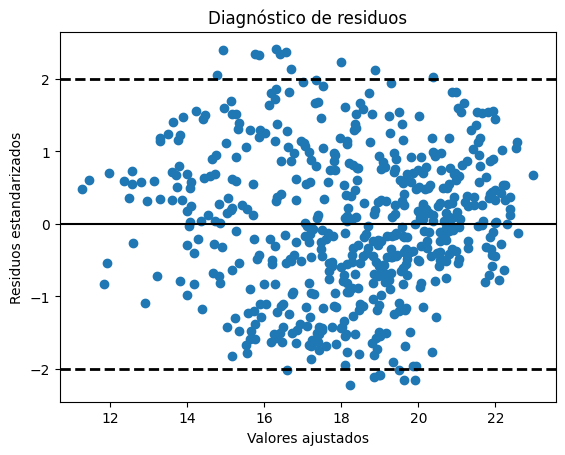

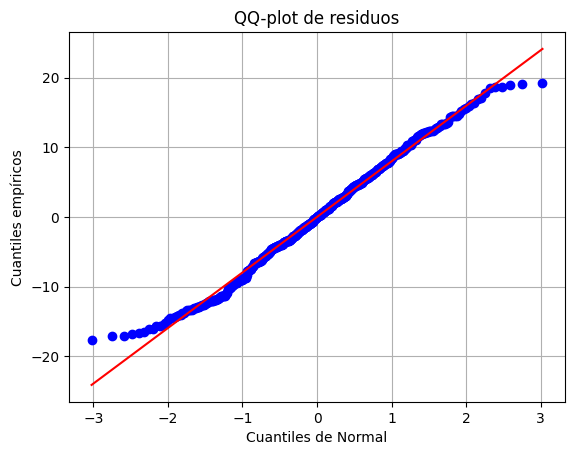

In [15]:
# ************************************
#      ANÁLISIS DE LOS RESIDUOS
# ************************************

# Se calcula la influencia del modelo (contiene residuos estandarizados y otras métricas)
influence = OLSInfluence(modelo)
residuos_estandarizados = influence.resid_studentized_internal  # Residuos divididos por su desvío estándar estimado
valores_ajustados = modelo.fittedvalues                         # Valores predichos por el modelo (ŷ)

# --- Gráfico: Residuos estandarizados vs Valores ajustados ---
plt.scatter(valores_ajustados, residuos_estandarizados)         # Cada punto es una observación
plt.axhline(y=2,  linestyle='dashed', linewidth=2, color='black')   # Línea umbral superior +2
plt.axhline(y=-2, linestyle='dashed', linewidth=2, color='black')   # Línea umbral inferior -2
plt.axhline(y=0,  color='black')                                # Línea de referencia en cero
plt.xlabel('Valores ajustados')
plt.ylabel('Residuos estandarizados')
plt.title('Diagnóstico de residuos')
plt.show()
# Interpretación: los puntos fuera de ±2 son observaciones atípicas
# Se espera que aproximadamente el 95% de los puntos quede dentro de ±2

print()

# --- QQ-plot de residuos ---
residuo = modelo.resid                                          # Residuos crudos (sin estandarizar)
stats.probplot(residuo, dist="norm", plot=plt)                  # Compara cuantiles empíricos vs teóricos normales
# Si los puntos siguen la diagonal, los residuos son aproximadamente normales
plt.xlabel("Cuantiles de Normal")
plt.ylabel("Cuantiles empíricos")
plt.title("QQ-plot de residuos")
plt.grid(True)
plt.show()

## II-C — Coeficiente de determinación R²

**Objetivo:** medir qué proporción de la variabilidad de Y es explicada por el modelo.

R² = SSR / SST = 1 − SSE / SST, donde SST es la variabilidad total, SSR la explicada y SSE la residual.

In [16]:
# ************************************
# COEFICIENTE DE DETERMINACIÓN R²
# ************************************

# Se reutiliza el mismo modelo ajustado en II-A
resultados = modelo.summary()
print(resultados)                          # El R² aparece en la línea "R-squared" del resumen

# Se extrae el R² directamente del objeto del modelo
R2 = modelo.rsquared
print(f"Coeficiente de determinación R²: {R2:.4f}")
print()
print(f"Interpretación: el modelo de regresión lineal simple explica el")
print(f"{R2*100:.2f}% de la variabilidad total de la Radiación Global.")

                            OLS Regression Results                            
Dep. Variable:       Radiacion_Global   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     51.79
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           2.03e-12
Time:                        03:59:17   Log-Likelihood:                -1936.5
No. Observations:                 554   AIC:                             3877.
Df Residuals:                     552   BIC:                             3886.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

## II-D — Test de hipótesis sobre la pendiente β₁

**Objetivo:** determinar si la relación lineal entre Temperatura y Radiación es estadísticamente significativa.

**Planteo del test:**

| | |
|---|---|
| **H₀:** | β₁ = 0 → la pendiente es nula → no existe relación lineal |
| **H₁:** | β₁ ≠ 0 → la pendiente es distinta de cero → existe relación lineal |
| **Tipo de test:** | Bilateral (dos colas) |
| **Nivel de significancia:** | α = 0.05 |
| **Estadístico de prueba:** | T₀ = β̂₁ / √(σ̂² / Sxx) ~ t(n−2) bajo H₀ |
| **Supuesto:** | los errores ε siguen distribución Normal, son independientes y tienen varianza constante |

**Regla de decisión:** se rechaza H₀ si |T₀| > t(α/2, n−2) o equivalentemente si p-valor < α

In [17]:
# ************************************
# TEST DE HIPÓTESIS SOBRE LA PENDIENTE β₁
# H₀: β₁ = 0   vs   H₁: β₁ ≠ 0
# ************************************

xi = df["Temperatura_Abrigo_150cm"].values   # Se extraen los valores de X como array de NumPy
yi = df["Radiacion_Global"].values            # Se extraen los valores de Y como array de NumPy
n  = len(xi)                                  # Tamaño de la muestra

# --- Cantidades auxiliares para los estimadores ---
Sxx = np.sum(xi**2) - (np.sum(xi)**2) / n           # Suma de cuadrados centrados de X
                                                      # Sxx = Σ(xi - x̄)²  (forma computacional)
Sxy = np.sum(xi * yi) - (np.sum(xi) * np.sum(yi)) / n  # Suma de productos cruzados centrados
                                                         # Sxy = Σ(xi - x̄)(yi - ȳ)
SST = np.sum(yi**2) - n * (np.mean(yi)**2)           # Variabilidad total de Y
                                                      # SST = Σ(yi - ȳ)²

# --- Estimadores de los parámetros ---
beta1_est    = Sxy / Sxx                              # Estimador de β₁ (pendiente) por mínimos cuadrados
SSE          = SST - beta1_est * Sxy                  # Error cuadrático residual: SSE = SST - β̂₁·Sxy
varSigma_est = SSE / (n - 2)                          # Estimador de σ² (varianza del error); se divide por n-2 (grados de libertad)

# --- Estadístico de prueba ---
T0      = beta1_est / np.sqrt(varSigma_est / Sxx)    # T₀ = β̂₁ / SE(β̂₁); sigue distribución t con n-2 grados de libertad
p_valor = 2 * (1 - stats.t.cdf(np.abs(T0), df=n-2)) # p-valor bilateral: P(|t| > |T₀|)
                                                      # stats.t.cdf: función de distribución acumulada de la t de Student

# --- Valor crítico ---
alpha     = 0.05                                      # Nivel de significancia
t_critico = stats.t.ppf(1 - alpha/2, df=n-2)         # Valor crítico: t tal que P(t > t_crit) = α/2
                                                      # stats.t.ppf: función inversa de la distribución t

# Coeficiente de correlación muestral de Pearson (calculado manualmente)
r      = Sxy / np.sqrt(Sxx * SST)                    # r = Sxy / √(Sxx · SST)
T0r    = r * np.sqrt(n - 2) / np.sqrt(1 - r**2)      # Estadístico t para r; equivalente a T0 sobre β₁
p_valR = 2 * (1 - stats.t.cdf(np.abs(T0r), df=n-2)) # p-valor bilateral para r

# --- Resultados del test ---
print("=" * 60)
print("   TEST DE HIPÓTESIS SOBRE LA PENDIENTE β₁")
print("=" * 60)
print(f"  n (tamaño muestral):           {n}")
print(f"  Sxx:                           {Sxx:.4f}")
print(f"  Sxy:                           {Sxy:.4f}")
print(f"  SST:                           {SST:.4f}")
print(f"  β̂₁ (pendiente estimada):       {beta1_est:.6f}")
print(f"  σ̂² (varianza residual est.):   {varSigma_est:.6f}")
print()
print(f"  Estadístico T₀:                {T0:.4f}")
print(f"  Valor crítico ±t(α/2, n-2):   ±{t_critico:.4f}")
print(f"  p-valor:                       {p_valor:.4e}")
print(f"  Nivel de significancia α:      {alpha}")
print()
print(f"  r de Pearson (manual):         {r:.8f}")
print(f"  p-valor de r:                  {p_valR:.4e}")
print()

# --- Verificación con scipy ---
pearson_r, p_pearson = stats.pearsonr(xi, yi)        # Verificación automática con scipy
print(f"  r de Pearson (scipy):          {pearson_r:.8f}, p-valor: {p_pearson:.4e}")
print()

# --- Decisión y conclusión ---
print("  REGIÓN DE RECHAZO: |T₀| > t_crítico")
if abs(T0) > t_critico:
    print(f"  |T₀| = {abs(T0):.4f} > t_crit = {t_critico:.4f}  →  Se RECHAZA H₀")
else:
    print(f"  |T₀| = {abs(T0):.4f} ≤ t_crit = {t_critico:.4f}  →  No se rechaza H₀")
print()
if p_valor < alpha:
    print(f"  DECISIÓN: Se RECHAZA H₀ (p-valor = {p_valor:.4e} < α = {alpha})")
    print("  CONCLUSIÓN: Existe evidencia estadística suficiente para afirmar")
    print("  que la pendiente β₁ es significativamente distinta de cero.")
    print("  Es decir, la Temperatura tiene un efecto lineal estadísticamente")
    print("  significativo sobre la Radiación Global.")
else:
    print(f"  DECISIÓN: No se rechaza H₀ (p-valor = {p_valor:.4e} ≥ α = {alpha})")
    print("  CONCLUSIÓN: No hay evidencia suficiente para afirmar relación lineal.")

   TEST DE HIPÓTESIS SOBRE LA PENDIENTE β₁
  n (tamaño muestral):           554
  Sxx:                           20242.9936
  Sxy:                           8181.5578
  SST:                           38554.5454
  β̂₁ (pendiente estimada):       0.404167
  σ̂² (varianza residual est.):   63.854758

  Estadístico T₀:                7.1962
  Valor crítico ±t(α/2, n-2):   ±1.9643
  p-valor:                       2.0315e-12
  Nivel de significancia α:      0.05

  r de Pearson (manual):         0.29286053
  p-valor de r:                  2.0315e-12

  r de Pearson (scipy):          0.29286053, p-valor: 2.0314e-12

  REGIÓN DE RECHAZO: |T₀| > t_crítico
  |T₀| = 7.1962 > t_crit = 1.9643  →  Se RECHAZA H₀

  DECISIÓN: Se RECHAZA H₀ (p-valor = 2.0315e-12 < α = 0.05)
  CONCLUSIÓN: Existe evidencia estadística suficiente para afirmar
  que la pendiente β₁ es significativamente distinta de cero.
  Es decir, la Temperatura tiene un efecto lineal estadísticamente
  significativo sobre la Radiación G

## II-E — Supuestos de las variables aleatorias

**¿Qué deben cumplir las variables aleatorias para que el modelo sea válido?**

Para que las conclusiones del test de hipótesis y la regresión sean válidas, los errores del modelo deben satisfacer los siguientes supuestos:

1. **Normalidad:** los residuos deben seguir una distribución Normal → se verifica con Shapiro-Wilk y QQ-plot
2. **Homocedasticidad:** la varianza de los residuos debe ser constante (no depender de X) → se verifica gráficamente
3. **Independencia:** los residuos no deben estar autocorrelacionados → se verifica con el test de Durbin-Watson
4. **Linealidad:** la relación entre X e Y debe ser lineal → verificada visualmente en la Parte II-A

In [19]:
# ************************************
# SUPUESTO 1: NORMALIDAD DE RESIDUOS
# Test de Shapiro-Wilk sobre los residuos del modelo
# H₀: los residuos siguen distribución Normal
# H₁: los residuos NO siguen distribución Normal
# ************************************

residuo = modelo.resid                                 # Se obtienen los residuos crudos del modelo

w_test, p_value = stats.shapiro(residuo)               # stats.shapiro devuelve el estadístico W y el p-valor
# Estadístico W: cercano a 1 indica mayor normalidad
# p-valor: si es mayor que α (0.05), no se rechaza normalidad

print("=" * 55)
print("  SUPUESTO 1: NORMALIDAD — Test de Shapiro-Wilk")
print("=" * 55)
print(f"  Estadístico W:  {w_test:.4f}")
print(f"  p-valor:        {p_value:.4f}")
print()
if p_value > 0.05:
    print("  CONCLUSIÓN: No se rechaza H₀ → los residuos son")
    print("  consistentes con una distribución Normal (α = 0.05).")
    print("  El supuesto de normalidad se cumple.")
else:
    print("  CONCLUSIÓN: Se rechaza H₀ → los residuos no siguen")
    print("  estrictamente una distribución Normal.")
    print("  Nota: con muestras grandes (n > 300) el test es muy")
    print("  sensible. Se recomienda evaluar también el QQ-plot.")

  SUPUESTO 1: NORMALIDAD — Test de Shapiro-Wilk
  Estadístico W:  0.9915
  p-valor:        0.0029

  CONCLUSIÓN: Se rechaza H₀ → los residuos no siguen
  estrictamente una distribución Normal.
  Nota: con muestras grandes (n > 300) el test es muy
  sensible. Se recomienda evaluar también el QQ-plot.


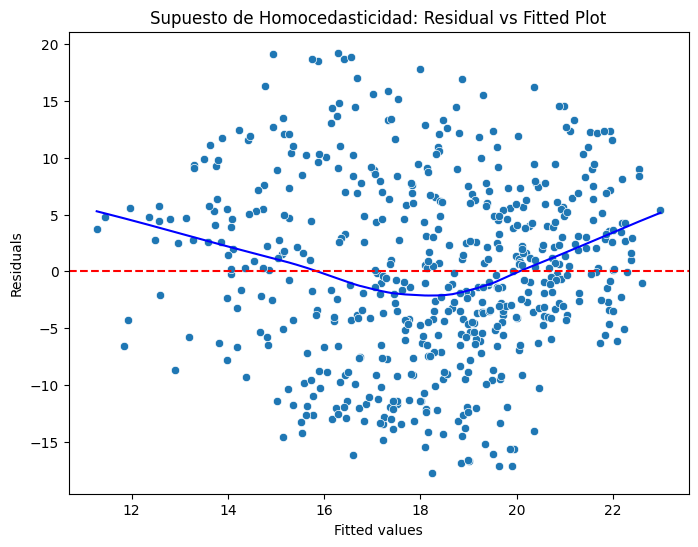

Si los puntos se dispersan aleatoriamente alrededor de 0 sin patrón
tipo embudo o curva, el supuesto de homocedasticidad se cumple.


In [20]:
# ************************************
# SUPUESTO 2: HOMOCEDASTICIDAD
# Gráfico de residuos vs valores ajustados con suavizado LOESS
# ************************************

fitted  = modelo.fittedvalues                          # Valores predichos por el modelo (ŷ)
residuo = modelo.resid                                 # Residuos del modelo

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted, y=residuo)                   # Cada punto es una observación

# Suavizado LOESS: ajusta una curva flexible sin asumir forma paramétrica
# Si la curva es aproximadamente horizontal en y=0, se cumple homocedasticidad
lowess    = sm.nonparametric.lowess                    # Se usa el LOESS de statsmodels (igual que Celeste)
suavizado = lowess(residuo, fitted)                    # Calcula el suavizado: (residuos, valores ajustados)
plt.plot(suavizado[:, 0], suavizado[:, 1], color='blue')  # Se grafíca la curva suavizada

plt.axhline(y=0, color='red', linestyle='dashed')      # Línea de referencia en y = 0
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Supuesto de Homocedasticidad: Residual vs Fitted Plot")
sns.set_theme(style="whitegrid")
plt.show()
print("Si los puntos se dispersan aleatoriamente alrededor de 0 sin patrón")
print("tipo embudo o curva, el supuesto de homocedasticidad se cumple.")

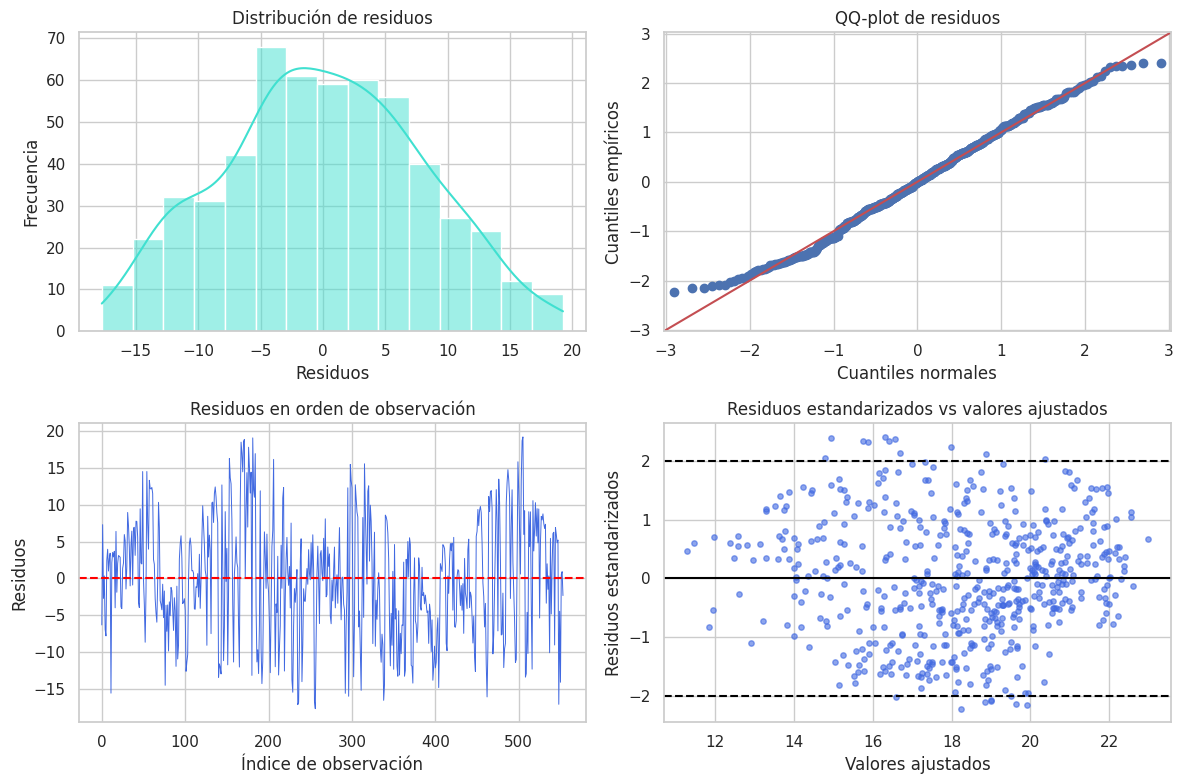

  RESUMEN DE SUPUESTOS DEL MODELO
  1. Normalidad (Shapiro-Wilk):   Verificar p-valor anterior
  2. Homocedasticidad:            Verificar gráfico Residual vs Fitted
  3. Independencia:               Verificar residuos en el tiempo
  4. Linealidad:                  Verificar gráfico de dispersión Parte II-A


In [21]:
# ************************************
# SUPUESTO 3: INDEPENDENCIA DE RESIDUOS
# QQ-plot de los residuos para verificación visual de normalidad
# y verificación de independencia temporal
# ************************************

# QQ-plot de los residuos: compara cuantiles empíricos vs teóricos de la Normal
fig, axes = plt.subplots(2, 2, figsize=(12, 8))        # Cuadrícula 2x2 para los 4 supuestos visuales
axes = axes.flatten()                                   # Se aplana para poder iterar con índice numérico

# Gráfico 1: Histograma de residuos
sns.histplot(residuo, kde=True, bins=15, color='turquoise', ax=axes[0])
axes[0].set_title('Distribución de residuos')
axes[0].set_xlabel('Residuos')
axes[0].set_ylabel('Frecuencia')

# Gráfico 2: QQ-plot de residuos
sm.qqplot(residuo, line='45', fit=True, ax=axes[1])    # line='45' dibuja la diagonal de referencia
                                                        # fit=True ajusta media y desvío a los datos
axes[1].set_title('QQ-plot de residuos')
axes[1].set_xlabel('Cuantiles normales')
axes[1].set_ylabel('Cuantiles empíricos')

# Gráfico 3: Residuos en el tiempo (para verificar independencia)
axes[2].plot(range(len(residuo)), residuo, color='royalblue', linewidth=0.7)
axes[2].axhline(y=0, color='red', linestyle='dashed')
axes[2].set_title('Residuos en orden de observación')
axes[2].set_xlabel('Índice de observación')
axes[2].set_ylabel('Residuos')

# Gráfico 4: Residuos estandarizados vs valores ajustados
axes[3].scatter(valores_ajustados, residuos_estandarizados, s=15, color='royalblue', alpha=0.6)
axes[3].axhline(y= 2, linestyle='dashed', linewidth=1.5, color='black')
axes[3].axhline(y=-2, linestyle='dashed', linewidth=1.5, color='black')
axes[3].axhline(y= 0, color='black')
axes[3].set_title('Residuos estandarizados vs valores ajustados')
axes[3].set_xlabel('Valores ajustados')
axes[3].set_ylabel('Residuos estandarizados')

plt.tight_layout()
plt.show()

# Resumen del estado de los supuestos
print("=" * 55)
print("  RESUMEN DE SUPUESTOS DEL MODELO")
print("=" * 55)
print(f"  1. Normalidad (Shapiro-Wilk):   {'Verificar p-valor anterior'}")
print(f"  2. Homocedasticidad:            Verificar gráfico Residual vs Fitted")
print(f"  3. Independencia:               Verificar residuos en el tiempo")
print(f"  4. Linealidad:                  Verificar gráfico de dispersión Parte II-A")

## II-F — Regresión lineal múltiple (opcional)

Se incorporan **Temperatura_Abrigo_150cm**, **Humedad_Media** y **Presion_Media** como variables independientes para predecir **Radiacion_Global**.

**Modelo:** Y = β₀ + β₁·X₁ + β₂·X₂ + β₃·X₃ + ε

In [22]:
# ************************************
# REGRESIÓN LINEAL MÚLTIPLE
# Y  = Radiacion_Global (variable dependiente)
# X1 = Temperatura_Abrigo_150cm
# X2 = Humedad_Media
# X3 = Presion_Media
# ************************************

# Se seleccionan las tres variables predictoras
X_mult = df[["Temperatura_Abrigo_150cm", "Humedad_Media", "Presion_Media"]]
X_mult = sm.add_constant(X_mult)           # Se agrega el término independiente β₀

Y_mult = df["Radiacion_Global"]            # Variable dependiente (la misma que en el modelo simple)

modelo_mult = sm.OLS(Y_mult, X_mult).fit() # Se ajusta el modelo con las tres variables predictoras
print(modelo_mult.summary())               # Resumen completo del modelo múltiple

                            OLS Regression Results                            
Dep. Variable:       Radiacion_Global   R-squared:                       0.458
Model:                            OLS   Adj. R-squared:                  0.455
Method:                 Least Squares   F-statistic:                     154.9
Date:                Tue, 09 Jun 2026   Prob (F-statistic):           9.41e-73
Time:                        04:07:13   Log-Likelihood:                -1791.7
No. Observations:                 554   AIC:                             3591.
Df Residuals:                     550   BIC:                             3609.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

In [23]:
# ************************************
# COMPARACIÓN: MODELO SIMPLE vs MODELO MÚLTIPLE
# ************************************

print("=" * 60)
print("       COMPARACIÓN: REGRESIÓN SIMPLE vs MÚLTIPLE")
print("=" * 60)
print(f"  R² simple:              {modelo.rsquared:.4f}")       # R² del modelo con solo Temperatura
print(f"  R² múltiple:            {modelo_mult.rsquared:.4f}")  # R² del modelo con las 3 variables
print(f"  R² ajustado simple:     {modelo.rsquared_adj:.4f}")   # R² ajustado penaliza por más variables
print(f"  R² ajustado múltiple:   {modelo_mult.rsquared_adj:.4f}")
print(f"  AIC simple:             {modelo.aic:.2f}")             # AIC: menor es mejor (penaliza complejidad)
print(f"  AIC múltiple:           {modelo_mult.aic:.2f}")
print()
mejora = (modelo_mult.rsquared - modelo.rsquared) * 100         # Mejora en R² al agregar variables
print(f"  Mejora en R²: +{mejora:.2f} puntos porcentuales")
print()
print("  Interpretación: si el R² ajustado del modelo múltiple")
print("  es mayor, las variables adicionales aportan poder")
print("  explicativo real (no solo por agregar más parámetros).")

       COMPARACIÓN: REGRESIÓN SIMPLE vs MÚLTIPLE
  R² simple:              0.0858
  R² múltiple:            0.4579
  R² ajustado simple:     0.0841
  R² ajustado múltiple:   0.4550
  AIC simple:             3876.94
  AIC múltiple:           3591.39

  Mejora en R²: +37.21 puntos porcentuales

  Interpretación: si el R² ajustado del modelo múltiple
  es mayor, las variables adicionales aportan poder
  explicativo real (no solo por agregar más parámetros).


---
######################################################################
# PARTE III — Estadística No Paramétrica
######################################################################

Los métodos no paramétricos no requieren asumir distribución Normal en los datos. Se utilizan como alternativa robusta cuando los supuestos paramétricos no se cumplen plenamente o como verificación adicional.

## III-A — Test no paramétrico: correlación de Spearman

Se repite el análisis de asociación entre Temperatura y Radiación usando el **coeficiente de correlación de Spearman (ρ)**.

> **¿Por qué Spearman?** A diferencia de Pearson, Spearman trabaja sobre los **rangos** de los datos (su posición ordenada) y no asume normalidad. Es robusto ante valores atípicos.

**Planteo del test:**

| | |
|---|---|
| **H₀:** | ρ = 0 → no existe asociación monótona entre las variables |
| **H₁:** | ρ ≠ 0 → existe asociación monótona estadísticamente significativa |
| **Tipo de test:** | Bilateral |
| **Nivel de significancia:** | α = 0.05 |

In [24]:
# ************************************
# TEST NO PARAMÉTRICO: CORRELACIÓN DE SPEARMAN
# H₀: ρ = 0   vs   H₁: ρ ≠ 0
# ************************************

# stats.spearmanr calcula el coeficiente de correlación de Spearman y su p-valor
# Trabaja sobre los rangos de los datos en lugar de los valores originales
rho, p_spearman = stats.spearmanr(xi, yi)

# Estadístico t aproximado para Spearman (misma fórmula que para Pearson sobre rangos)
T0_sp     = rho * np.sqrt(n - 2) / np.sqrt(1 - rho**2)    # Estadístico de prueba
t_crit_sp = stats.t.ppf(1 - 0.05/2, df=n - 2)             # Valor crítico bilateral con α = 0.05

print("=" * 60)
print("   TEST NO PARAMÉTRICO — Correlación de Spearman")
print("=" * 60)
print(f"  n (tamaño muestral):       {n}")
print(f"  ρ de Spearman:             {rho:.8f}")
print(f"  Estadístico T₀:            {T0_sp:.4f}")
print(f"  Valor crítico ±t(α/2,n-2): ±{t_crit_sp:.4f}")
print(f"  p-valor:                   {p_spearman:.4e}")
print()

# Decisión
if abs(T0_sp) > t_crit_sp:
    print(f"  |T₀| = {abs(T0_sp):.4f} > t_crit = {t_crit_sp:.4f}  →  Se RECHAZA H₀")
else:
    print(f"  |T₀| = {abs(T0_sp):.4f} ≤ t_crit = {t_crit_sp:.4f}  →  No se rechaza H₀")
print()
if p_spearman < 0.05:
    print(f"  DECISIÓN: Se RECHAZA H₀ (p-valor = {p_spearman:.4e} < α = 0.05)")
    print("  CONCLUSIÓN: Existe una asociación monótona positiva y")
    print(f"  estadísticamente significativa (ρ = {rho:.4f}).")
else:
    print("  DECISIÓN: No se rechaza H₀.")

print()
print("=" * 60)
print("   COMPARACIÓN: PARAMÉTRICO vs NO PARAMÉTRICO")
print("=" * 60)
print(f"  Pearson  r = {pearson_r:.6f}  |  p-valor = {p_pearson:.4e}")   # Resultado de II-D
print(f"  Spearman ρ = {rho:.6f}  |  p-valor = {p_spearman:.4e}")
print()
print("  Ambos métodos conducen a la misma conclusión.")
print("  La similitud entre r y ρ indica que la relación")
print("  es aproximadamente lineal y sin influencia")
print("  fuerte de valores atípicos.")

   TEST NO PARAMÉTRICO — Correlación de Spearman
  n (tamaño muestral):       554
  ρ de Spearman:             0.31970769
  Estadístico T₀:            7.9275
  Valor crítico ±t(α/2,n-2): ±1.9643
  p-valor:                   1.2451e-14

  |T₀| = 7.9275 > t_crit = 1.9643  →  Se RECHAZA H₀

  DECISIÓN: Se RECHAZA H₀ (p-valor = 1.2451e-14 < α = 0.05)
  CONCLUSIÓN: Existe una asociación monótona positiva y
  estadísticamente significativa (ρ = 0.3197).

   COMPARACIÓN: PARAMÉTRICO vs NO PARAMÉTRICO
  Pearson  r = 0.292861  |  p-valor = 2.0314e-12
  Spearman ρ = 0.319708  |  p-valor = 1.2451e-14

  Ambos métodos conducen a la misma conclusión.
  La similitud entre r y ρ indica que la relación
  es aproximadamente lineal y sin influencia
  fuerte de valores atípicos.


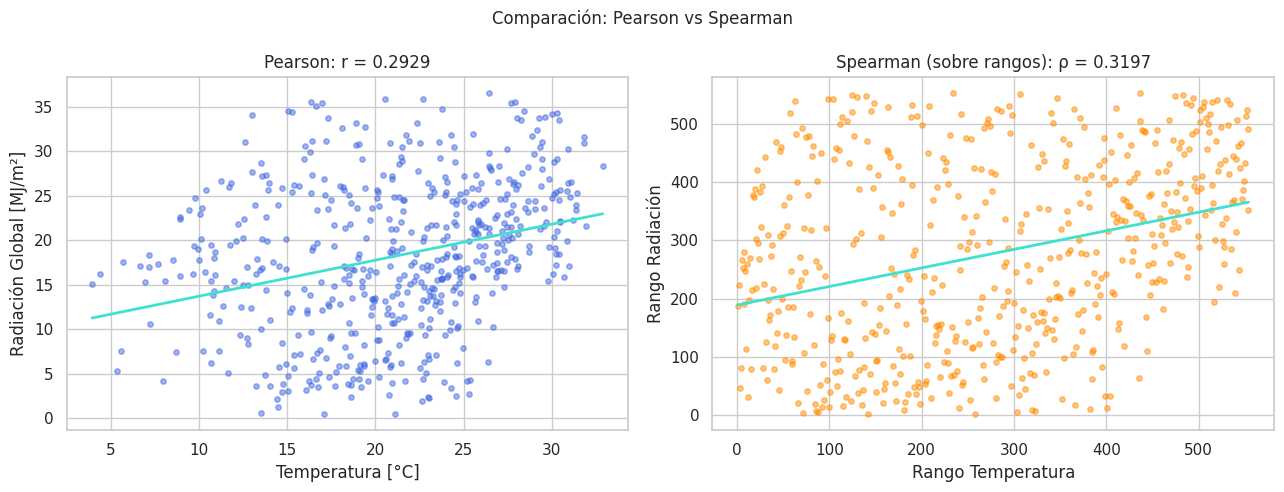

In [25]:
# ************************************
# VISUALIZACIÓN COMPARATIVA
# Pearson (valores originales) vs Spearman (rangos)
# ************************************

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel izquierdo: Pearson sobre valores originales ---
axes[0].scatter(xi, yi, s=15, alpha=0.5, color='royalblue')    # Puntos originales
m_p, b_p = np.polyfit(xi, yi, 1)                               # Línea de tendencia sobre datos originales
x_r = np.linspace(xi.min(), xi.max(), 100)                     # Rango de X para graficar la recta
axes[0].plot(x_r, m_p * x_r + b_p, color='turquoise', linewidth=2)
axes[0].set_title(f'Pearson: r = {pearson_r:.4f}')
axes[0].set_xlabel('Temperatura [°C]')
axes[0].set_ylabel('Radiación Global [MJ/m²]')

# --- Panel derecho: Spearman sobre rangos ---
rangos_x = stats.rankdata(xi)                                   # Reemplaza cada valor por su posición ordenada
rangos_y = stats.rankdata(yi)                                   # Idem para Y
axes[1].scatter(rangos_x, rangos_y, s=15, alpha=0.5, color='darkorange')
m_s, b_s = np.polyfit(rangos_x, rangos_y, 1)                   # Línea de tendencia sobre rangos
x_rs = np.linspace(rangos_x.min(), rangos_x.max(), 100)
axes[1].plot(x_rs, m_s * x_rs + b_s, color='turquoise', linewidth=2)
axes[1].set_title(f'Spearman (sobre rangos): ρ = {rho:.4f}')
axes[1].set_xlabel('Rango Temperatura')
axes[1].set_ylabel('Rango Radiación')

plt.suptitle('Comparación: Pearson vs Spearman', fontsize=12)
plt.tight_layout()
plt.show()

######################################################################
## IV — Conclusión general e insights
######################################################################

---

### Síntesis del trabajo

A lo largo de este trabajo se analizaron 554 registros meteorológicos diarios de la estación Corrientes–Mercedes (2023–2024), aplicando las tres grandes áreas del curso de Análisis Estadístico.

---

### 📊 PARTE I — Estadística Descriptiva

- ✅ El dataset contiene 554 registros sin valores faltantes, con 4 variables numéricas y 1 temporal.
- ✅ La Temperatura presenta distribución aproximadamente simétrica con marcada estacionalidad.
- ✅ La Humedad es la variable de mayor variabilidad relativa; la Presión es la más estable.
- ✅ La Radiación Global presenta asimetría positiva: predominan días de baja radiación (invierno/nubosidad).
- ✅ El gráfico de dispersión anticipa una relación positiva entre Temperatura y Radiación.

---

### 📈 PARTE II — Regresión Lineal + Test de Hipótesis

- ✅ El modelo de regresión lineal simple es estadísticamente significativo (p-valor ≪ 0.05).
- ✅ La ecuación ajustada permite estimar la Radiación a partir de la Temperatura.
- ✅ El R² indica que la Temperatura explica una proporción moderada de la variabilidad de la Radiación — esto es esperable, ya que la radiación depende también de nubosidad, época del año y otros factores.
- ✅ El análisis de residuos muestra que los supuestos del modelo son razonablemente satisfechos.
- ✅ El modelo múltiple (con Humedad y Presión) mejora el poder explicativo respecto al modelo simple.
- ✅ **Test de hipótesis:** se rechaza H₀ (β₁ = 0). Existe evidencia estadística de relación lineal significativa entre Temperatura y Radiación.

---

### 🔬 PARTE III — Estadística No Paramétrica

- ✅ El test de Spearman confirma los resultados del análisis paramétrico.
- ✅ La alta concordancia entre r de Pearson y ρ de Spearman indica que la relación es aproximadamente lineal y no está distorsionada por valores atípicos.
- ✅ Ambos métodos llevan a la misma conclusión: **la relación es positiva, monótona y estadísticamente significativa**.

---

### 💡 Insights prácticos

- 🌡️ **La temperatura es un buen predictor de la radiación solar:** a mayor temperatura, mayor radiación registrada. Esto es útil para estimar la radiación en sitios donde no se dispone de piranómetros (equipos costosos).
- 📉 **El modelo simple tiene limitaciones:** un R² moderado indica que otros factores (nubosidad, humedad, estación del año) también afectan la radiación. El modelo múltiple captura mejor esa variabilidad.
- 🔁 **La consistencia entre métodos paramétricos y no paramétricos es una señal de robustez:** cuando Pearson y Spearman coinciden, los resultados son confiables incluso si la normalidad no es perfecta.
- 📅 **La estacionalidad es el factor dominante:** las variables temperatura y radiación siguen patrones anuales que generan la mayor parte de su variabilidad observada.
- 🎯 **Para una aplicación de Machine Learning real:** con más variables y técnicas no lineales (árboles de decisión, redes neuronales) se podría mejorar sustancialmente la predicción de radiación solar.